In [20]:
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import glob
from tifffile import TiffFile
from tifffile import imread
from pathlib import Path
import os

plt.style.use('../libs/my_style.mplstyle')

root = Path('/mnt/NAS-Ebanaru/Sasaki/MTsingleBeads')
root = Path('/Volumes/data/Sasaki/MTsingleBeads')

folder = root / "beads7um" / "20260608" / "beads7um"
beads = pd.read_csv(folder / "beads_tracks.csv")
flow = folder / "GFP_flows.h5"

GFPs = folder / "GFP"

GFPs_list = []

for file in sorted(glob.glob(str(GFPs / '*'))):
    GFPs_list.append(imread(file))


KeyboardInterrupt: 

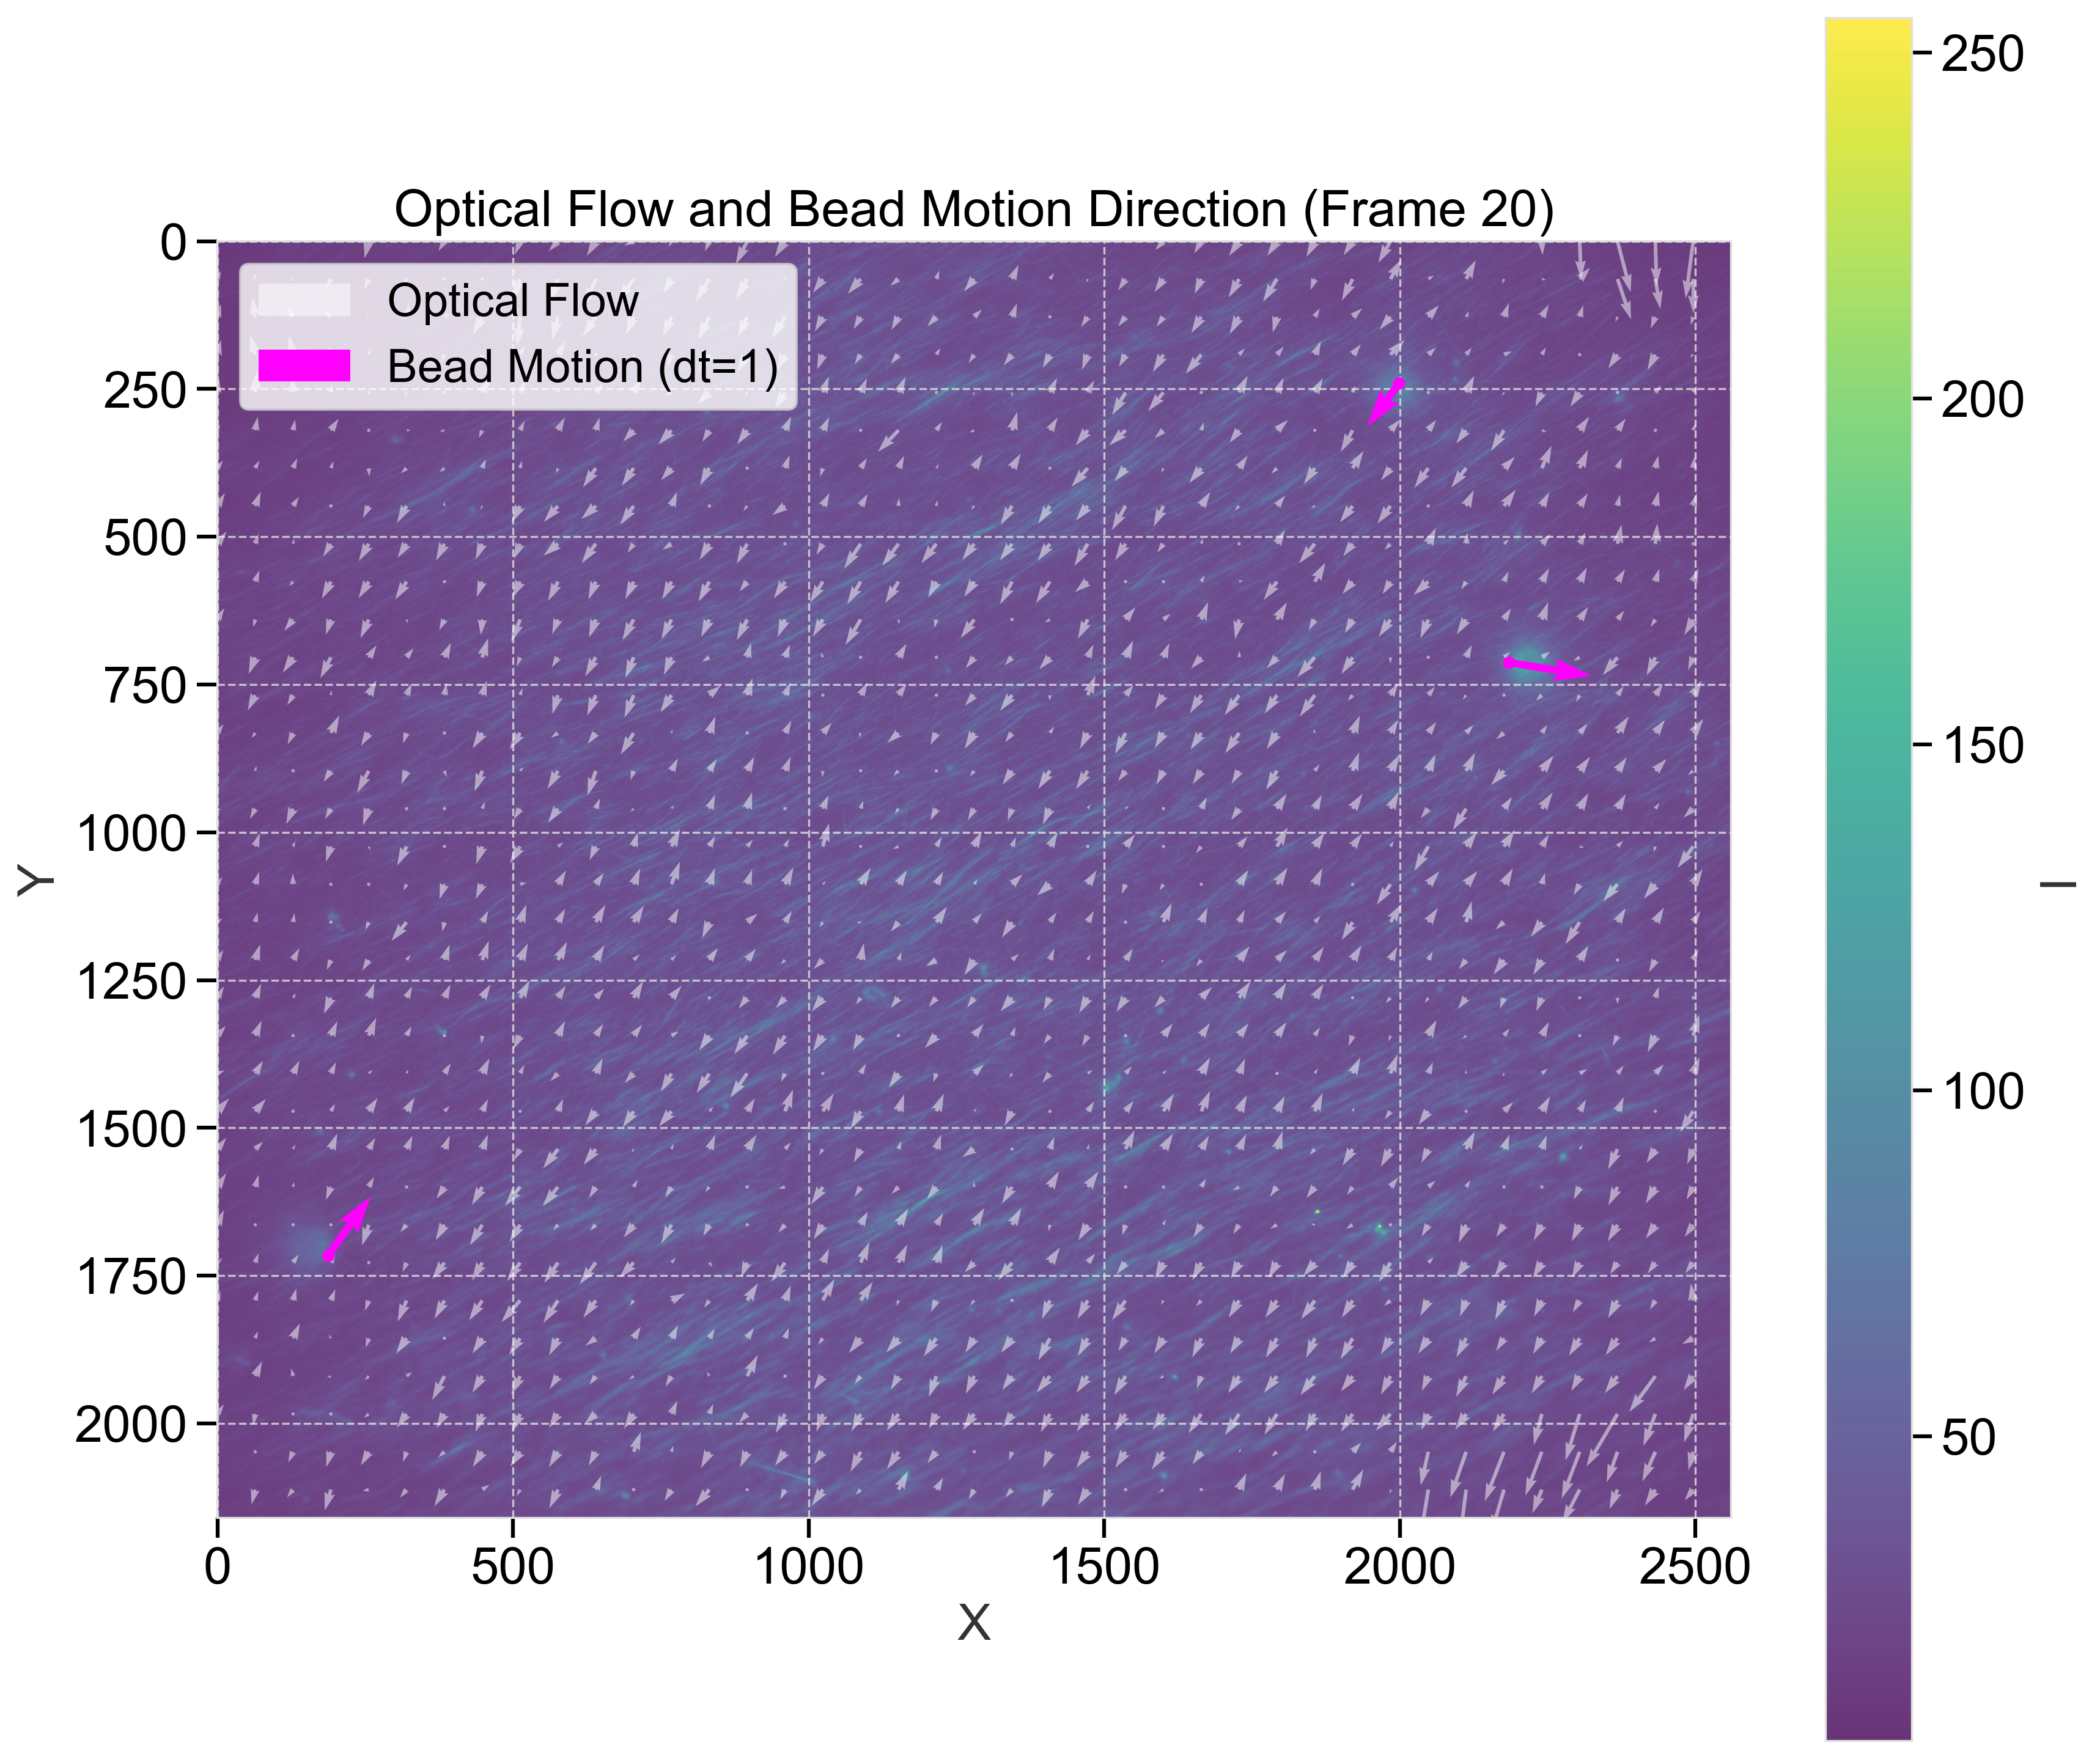

In [23]:
frame = 20


# GFP_flows.h5からフレーム0の流れ場を取得
with h5py.File(flow, 'r') as f:
    # f['flows'] のshapeは (T, 2, H, W) 
    flow_data = f['flows'][frame].astype(np.float32)

# 流れ場の大きさ(magnitude)を計算
# チャネル0と1がそれぞれ y(v), x(u) 方向のフローと仮定
v = flow_data[0]
u = flow_data[1]
magnitude = np.sqrt(u**2 + v**2)

# ベクトルを描画する場合はダウンサンプリングする
step = 64
y_grid, x_grid = np.mgrid[0:magnitude.shape[0]:step, 0:magnitude.shape[1]:step]
u_down = u[::step, ::step]
v_down = v[::step, ::step]

fig, ax = plt.subplots(figsize=(12, 10))

# 背景に流れ場の大きさをヒートマップとしてプロット
"""
im = ax.imshow(magnitude, cmap='viridis', origin='upper', alpha=0.8)
plt.colorbar(im, ax=ax, label='Flow Magnitude')
"""

im = ax.imshow(GFPs_list[frame], cmap='viridis', origin='upper', alpha=0.8)
plt.colorbar(im, ax=ax, label='I')

# 描画する矢印のスケール（値が小さいほど矢印が長く描画される）
# scale_units='xy' とすることで、流れ場とビーズの変位の長さを比較可能にする
shared_scale = 0.5 

# 流れ場の向きを矢印でプロット（Quiver、白色）
ax.quiver(x_grid, y_grid, u_down, v_down, color='white', alpha=0.5, 
          angles='xy', scale_units='xy', scale=shared_scale, label='Optical Flow')

# ビーズの運動方向（フレーム0からフレームdtへの変位）を計算
dt = 1 # 何フレーム先との差分をとるか
bx, by, b_dx, b_dy = [], [], [], []

# フレーム0に存在する全パーティクルについて
for p in beads[beads['frame'] == frame]['particle'].unique():
    track = beads[beads['particle'] == p]
    f0_data = track[track['frame'] == frame]
    ft_data = track[track['frame'] == dt]
    
    if not f0_data.empty and not ft_data.empty:
        x0, y0 = f0_data['x'].values[0], f0_data['y'].values[0]
        xt, yt = ft_data['x'].values[0], ft_data['y'].values[0]
        
        bx.append(x0)
        by.append(y0)
        b_dx.append(xt - x0)
        b_dy.append(yt - y0)

# ビーズの運動方向をマゼンタの矢印で描画（速度場と区別）
if len(bx) > 0:
    ax.quiver(bx, by, b_dx, b_dy, color='magenta', width=0.005,
              angles='xy', scale_units='xy', scale=shared_scale, label=f'Bead Motion (dt={dt})')
    # 初期位置を点で強調
    ax.scatter(bx, by, color='magenta', s=15, zorder=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Optical Flow and Bead Motion Direction (Frame {frame})')
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
frame = 20


# GFP_flows.h5からフレーム0の流れ場を取得
with h5py.File(flow, 'r') as f:
    # f['flows'] のshapeは (T, 2, H, W) 
    flow_data = f['flows'][frame].astype(np.float32)

# 流れ場の大きさ(magnitude)を計算
# チャネル0と1がそれぞれ y(v), x(u) 方向のフローと仮定
v = flow_data[0]
u = flow_data[1]
magnitude = np.sqrt(u**2 + v**2)

# ベクトルを描画する場合はダウンサンプリングする
step = 64
y_grid, x_grid = np.mgrid[0:magnitude.shape[0]:step, 0:magnitude.shape[1]:step]
u_down = u[::step, ::step]
v_down = v[::step, ::step]

fig, ax = plt.subplots(figsize=(12, 10))

# 背景に流れ場の大きさをヒートマップとしてプロット
im = ax.imshow(magnitude, cmap='viridis', origin='upper', alpha=0.8)
plt.colorbar(im, ax=ax, label='Flow Magnitude')

# 描画する矢印のスケール（値が小さいほど矢印が長く描画される）
# scale_units='xy' とすることで、流れ場とビーズの変位の長さを比較可能にする
shared_scale = 0.5 

# 流れ場の向きを矢印でプロット（Quiver、白色）
ax.quiver(x_grid, y_grid, u_down, v_down, color='white', alpha=0.5, 
          angles='xy', scale_units='xy', scale=shared_scale, label='Optical Flow')

# ビーズの運動方向（フレーム0からフレームdtへの変位）を計算
dt = 1 # 何フレーム先との差分をとるか
bx, by, b_dx, b_dy = [], [], [], []

# フレーム0に存在する全パーティクルについて
for p in beads[beads['frame'] == frame]['particle'].unique():
    track = beads[beads['particle'] == p]
    f0_data = track[track['frame'] == frame]
    ft_data = track[track['frame'] == dt]
    
    if not f0_data.empty and not ft_data.empty:
        x0, y0 = f0_data['x'].values[0], f0_data['y'].values[0]
        xt, yt = ft_data['x'].values[0], ft_data['y'].values[0]
        
        bx.append(x0)
        by.append(y0)
        b_dx.append(xt - x0)
        b_dy.append(yt - y0)

# ビーズの運動方向をマゼンタの矢印で描画（速度場と区別）
if len(bx) > 0:
    ax.quiver(bx, by, b_dx, b_dy, color='magenta', width=0.005,
              angles='xy', scale_units='xy', scale=shared_scale, label=f'Bead Motion (dt={dt})')
    # 初期位置を点で強調
    ax.scatter(bx, by, color='magenta', s=15, zorder=5)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title(f'Optical Flow and Bead Motion Direction (Frame {frame})')
ax.legend()

plt.tight_layout()
plt.show()
